## Previsão do Credito de Descarbonização

In [3]:
from darts import TimeSeries
import pandas as pd
import matplotlib.pyplot as plt
import os
# from darts.utils.statistics import extract_trend_and_seasonality
# from darts.utils.utils import ModelMode
# from darts.models import XGBModel
# from darts.models import LightGBMModel
# from darts.metrics import mape
import optuna
# from darts.utils.statistics import plot_residuals_analysis
# from darts.utils.missing_values import fill_missing_values
# from darts.dataprocessing.transformers import Scaler
# from darts.utils.timeseries_generation import constant_timeseries

In [4]:
import os
print(os.getcwd())

C:\Users\aryck\Desktop\hackathon_instituto_e+\example\2_mercado_descarbonizacao


In [6]:
CBIO = pd.read_csv('data/credito_descarbonizacao.csv')
CBIO

,Data,Preço Médio,Emissor
0,2020-04-28,50.500000,50787
1,2020-04-29,50.500000,114144
2,2020-04-30,50.500000,114144
3,2020-05-01,50.500000,114144
4,2020-05-02,50.500000,114144
...,...,...,...
2021,2026-05-04,29.178102,13829029
2022,2026-05-05,29.122054,13883882
2023,2026-05-06,29.101124,13806434
2024,2026-05-07,29.094924,13680257


## Darts

In [43]:
CBIO_series = TimeSeries.from_dataframe(
    CBIO,
    time_col='Data',
    value_cols=['Preço Médio', 'Emissor'],
    fill_missing_dates=True,
    freq='D'
)

CBIO_scaler = Scaler()
emissor_scaler = Scaler()

CBIO_scaled = CBIO_scaler.fit_transform(CBIO_series.univariate_component(0))
emissor_scaled = emissor_scaler.fit_transform(CBIO_series.univariate_component(1))

CBIO_train , CBIO_val = CBIO_scaled.split_before(0.80)
emissor_train , emissor_val = emissor_scaled.split_before(0.85)

train_list_incial = [CBIO_train,CBIO_val]
val_list = [emissor_train,emissor_val]

<Axes: xlabel='Data'>

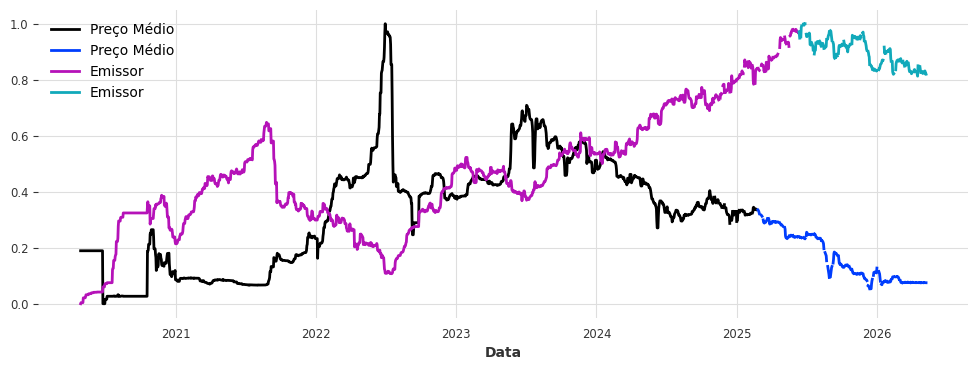

In [44]:
plt.figure(figsize=(12,4))
CBIO_train.plot()
CBIO_val.plot()
emissor_train.plot()
emissor_val.plot()

In [ ]:
##Definição de função objetiva
def objective(trial,model_approach):
    global model
    
    params = {
        "lags": trial.suggest_int("lags", 1,12),
        "output_chunk_length": trial.suggest_int("output_chunk_length", 2,100),
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 1e-2, 0.1, log=True),
        "depth": trial.suggest_int("depth", 1, 12),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 40, 100),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 6, 10),
        'boosting_type': trial.suggest_categorical('boosting_type', ['Ordered', 'Plain']),
        'eval_metric': "mae",
        'likelihood':'quantile',
        'quantiles':[0.1,0.5,0.9]
    }

    model = LightGBMModel(**params, multi_models = True)
    
    model.fit(CBIO_train)

    # model.save(f'models/Catboost/{model_approach}_trial_{trial.number}.pkl')
 
    predictions = model.predict(n=len(CBIO_val)+36)

    score = mape(CBIO_val,predictions)
    return score

def callback(study,trial):
    global best_model
    if study.best_trial == trial:
        best_model = model

## Definição do objeto study do optuna
study = optuna.create_study(direction = "minimize")

study.optimize(lambda trial: objective(trial, 'sem_choque'), n_trials=50, callbacks=[callback], show_progress_bar=True)

In [57]:
def callback(study, trial):

    global best_model

    if study.best_trial == trial:
        best_model = mode

study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=50,
    callbacks=[callback],
    show_progress_bar=True
)

[I 2026-05-10 05:21:45,775] A new study created in memory with name: no-name-9cfbf6c9-f05d-4b9b-b988-6e01b230bb35
  0%|                                                                                           | 0/50 [00:00<?, ?it/s]

[W 2026-05-10 05:21:45,792] Trial 0 failed with parameters: {'lags': 59, 'output_chunk_length': 25, 'learning_rate': 0.0227537419768959, 'n_estimators': 675, 'max_depth': 6, 'num_leaves': 190, 'min_child_samples': 77, 'subsample': 0.9451426171886776, 'colsample_bytree': 0.5878349634896065} because of the following error: ImportError('The `LightGBM` module could not be imported. To enable LightGBM support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md').
Traceback (most recent call last):
  File "C:\Users\aryck\miniconda3\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\aryck\AppData\Local\Temp\ipykernel_30156\1242683156.py", line 67, in objective
    model = LightGBMModel(**params)
  File "C:\Users\aryck\miniconda3\Lib\site-packages\darts\utils\utils.py", line 86, in __call__
    def __call__(self, *args, **kwargs):
        ^^^^^^^^^^^^^

ImportError: The `LightGBM` module could not be imported. To enable LightGBM support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md

In [ ]:
import optuna
import matplotlib.pyplot as plt

from darts.models import Prophet
from darts.metrics import mape

best_model = None
model = None

def objective(trial):

    global model
    params = {

        "yearly_seasonality": trial.suggest_categorical(
            "yearly_seasonality",
            [True, False]
        ),

        "weekly_seasonality": trial.suggest_categorical(
            "weekly_seasonality",
            [True, False]
        ),

        "daily_seasonality": False,

        "changepoint_prior_scale": trial.suggest_float(
            "changepoint_prior_scale",
            0.001,
            0.5,
            log=True
        ),

        "seasonality_prior_scale": trial.suggest_float(
            "seasonality_prior_scale",
            0.01,
            10,
            log=True
        ),

        "seasonality_mode": trial.suggest_categorical(
            "seasonality_mode",
            ["additive", "multiplicative"]
        )
    }

    model = Prophet(**params)

    model.fit(preco_train)

    predictions = model.predict(
        n=len(preco_val)
    )

    score = mape(
        preco_val,
        predictions
    )

    return score

# Callback
def callback(study, trial):

    global best_model

    if study.best_trial == trial:
        best_model = model

# Study Optuna
study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=30,
    callbacks=[callback],
    show_progress_bar=True
)

# Resultados
print("\n===================================")
print("Melhor Trial")
print("===================================")

print(f"Trial: {study.best_trial.number}")

print(f"\nMAPE: {study.best_value:.4f}")

print("\nBest Params:")
print(study.best_params)

future = best_model.predict(n=36)

# Plot
plt.figure(figsize=(14,6))
preco_series.plot(label='Série Completa')
future.plot(label='Forecast 36 dias')
plt.title('Forecast CBIO - Prophet')
plt.legend()
plt.grid(True)
plt.show()

In [63]:
from darts.models import Prophet

print("Prophet OK")

Prophet OK


## Prophet

15:45:15 - cmdstanpy - INFO - Chain [1] start processing
15:45:17 - cmdstanpy - INFO - Chain [1] done processing


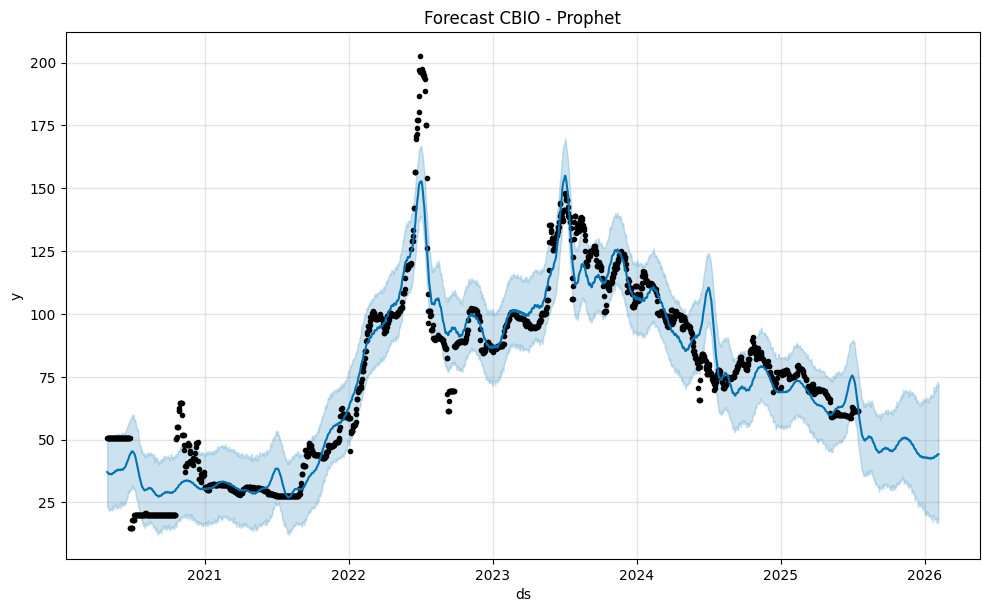

In [7]:
from prophet import Prophet

import pandas as pd
import matplotlib.pyplot as plt

# Dataset
df = CBIO[['Data', 'Preço Médio']].copy()

df.columns = ['ds', 'y']

# Train / Validation
split = int(len(df) * 0.9)

train = df.iloc[:split]
val = df.iloc[split:]

# Modelo
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

model.fit(train)

# Forecast validação
future = model.make_future_dataframe(
    periods=len(val),
    freq='D'
)

forecast = model.predict(future)

# Plot
fig = model.plot(forecast)
plt.title("Forecast CBIO - Prophet")
plt.show()

[I 2026-05-10 15:55:39,271] A new study created in memory with name: no-name-d8176a9a-2c55-43cb-b817-1c538d8a3aaf
  0%|                                                                                           | 0/80 [00:00<?, ?it/s]15:55:40 - cmdstanpy - INFO - Chain [1] start processing
15:55:40 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 0.262478:   1%|▌                                             | 1/80 [00:01<02:37,  2.00s/it]15:55:41 - cmdstanpy - INFO - Chain [1] start processing


[I 2026-05-10 15:55:41,312] Trial 0 finished with value: 0.26247839622874886 and parameters: {'changepoint_prior_scale': 0.009164737098533625, 'seasonality_prior_scale': 0.011827678185881103, 'holidays_prior_scale': 3.5067404106936415, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.7130626215633662, 'n_changepoints': 33, 'yearly_seasonality': True, 'weekly_seasonality': True}. Best is trial 0 with value: 0.26247839622874886.


15:55:41 - cmdstanpy - INFO - Chain [1] done processing
15:55:41 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
15:55:42 - cmdstanpy - INFO - Chain [1] start processing
15:55:43 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 0.262478:   2%|█▏                                            | 2/80 [00:05<03:52,  2.98s/it]15:55:45 - cmdstanpy - INFO - Chain [1] start processing


[I 2026-05-10 15:55:44,991] Trial 1 finished with value: 0.5355082866655262 and parameters: {'changepoint_prior_scale': 0.07916204153832651, 'seasonality_prior_scale': 19.088732554397975, 'holidays_prior_scale': 0.05222462838571656, 'seasonality_mode': 'additive', 'changepoint_range': 0.9203881887345139, 'n_changepoints': 10, 'yearly_seasonality': False, 'weekly_seasonality': True}. Best is trial 0 with value: 0.26247839622874886.


15:55:46 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 0.262478:   4%|█▋                                            | 3/80 [00:07<03:17,  2.56s/it]

...

[I 2026-05-10 15:57:37,090] Trial 77 finished with value: 0.9904521098319153 and parameters: {'changepoint_prior_scale': 0.3359134117689736, 'seasonality_prior_scale': 2.845709758385281, 'holidays_prior_scale': 0.07752282466073862, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.8944468155002273, 'n_changepoints': 28, 'yearly_seasonality': True, 'weekly_seasonality': True}. Best is trial 60 with value: 0.11640848976709521.


15:57:37 - cmdstanpy - INFO - Chain [1] start processing
15:57:39 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 60. Best value: 0.116408:  99%|███████████████████████████████████████████▍| 79/80 [02:00<00:02,  2.50s/it]

[I 2026-05-10 15:57:40,113] Trial 78 finished with value: 0.3900062837220187 and parameters: {'changepoint_prior_scale': 0.25369317492261717, 'seasonality_prior_scale': 4.958124313001217, 'holidays_prior_scale': 0.10909132482703562, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.8615226803017093, 'n_changepoints': 42, 'yearly_seasonality': True, 'weekly_seasonality': True}. Best is trial 60 with value: 0.11640848976709521.


15:57:40 - cmdstanpy - INFO - Chain [1] start processing
15:57:41 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 60. Best value: 0.116408: 100%|████████████████████████████████████████████| 80/80 [02:02<00:00,  1.53s/it]


[I 2026-05-10 15:57:41,942] Trial 79 finished with value: 0.1538196062103396 and parameters: {'changepoint_prior_scale': 0.19013969373168013, 'seasonality_prior_scale': 0.8686894535340574, 'holidays_prior_scale': 0.03335887941228384, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.8827126323157353, 'n_changepoints': 33, 'yearly_seasonality': True, 'weekly_seasonality': True}. Best is trial 60 with value: 0.11640848976709521.

Melhor Trial
Trial: 60

MAPE: 0.11641

Melhores parâmetros:
{'changepoint_prior_scale': 0.4025098810493798, 'seasonality_prior_scale': 1.931019329338666, 'holidays_prior_scale': 0.035162076886308215, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.8668964687123399, 'n_changepoints': 38, 'yearly_seasonality': True, 'weekly_seasonality': True}


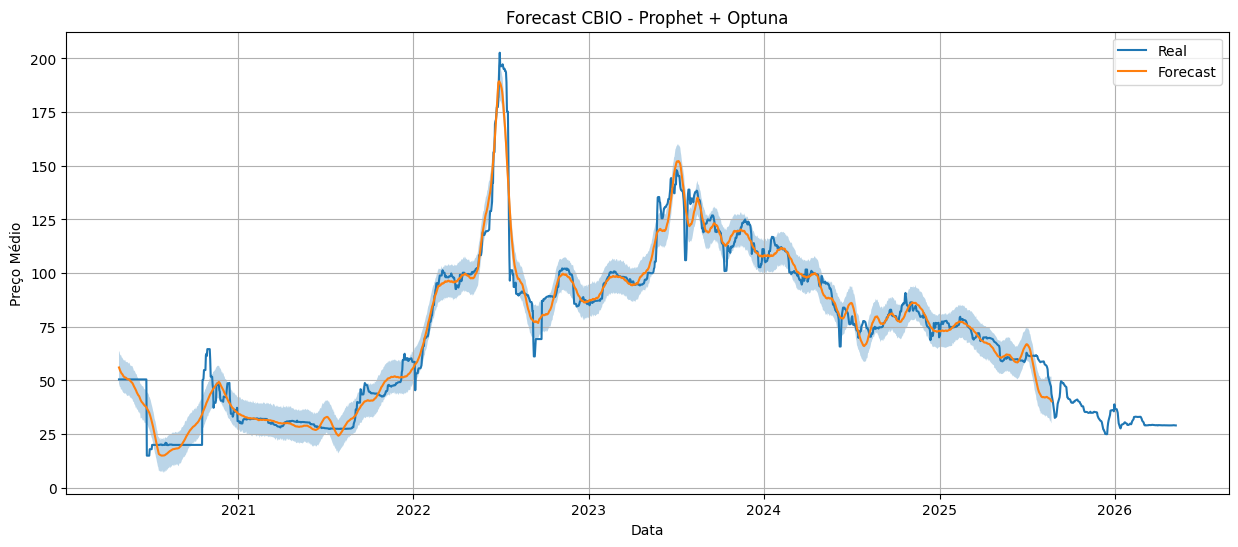

In [14]:
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error


# Dataset
df = CBIO[['Data', 'Preço Médio']].copy()

df.columns = ['ds', 'y']

df['ds'] = pd.to_datetime(df['ds'])

df = df.sort_values('ds').reset_index(drop=True)


# Train / Validation
split = int(len(df) * 0.90)

train = df.iloc[:split]
val = df.iloc[split:]


# Variáveis globais
best_model = None
best_forecast = None


# Função Objetivo
def objective(trial):

    global best_model
    global best_forecast
    # Hiperparâmetros
    params = {

        "changepoint_prior_scale": trial.suggest_float(
            "changepoint_prior_scale",
            0.001,
            0.5,
            log=True
        ),

        "seasonality_prior_scale": trial.suggest_float(
            "seasonality_prior_scale",
            0.01,
            20,
            log=True
        ),

        "holidays_prior_scale": trial.suggest_float(
            "holidays_prior_scale",
            0.01,
            20,
            log=True
        ),

        "seasonality_mode": trial.suggest_categorical(
            "seasonality_mode",
            ["additive", "multiplicative"]
        ),

        "changepoint_range": trial.suggest_float(
            "changepoint_range",
            0.7,
            0.95
        ),

        "n_changepoints": trial.suggest_int(
            "n_changepoints",
            5,
            50
        ),

        "yearly_seasonality": trial.suggest_categorical(
            "yearly_seasonality",
            [True, False]
        ),

        "weekly_seasonality": trial.suggest_categorical(
            "weekly_seasonality",
            [True, False]
        ),

        "daily_seasonality": False
    }
    # Modelo
    model = Prophet(**params)
    # Treinamento
    model.fit(train)
    # Forecast
    future = model.make_future_dataframe(
        periods=len(val),
        freq='D'
    )

    forecast = model.predict(future)
    # Apenas janela de validação
    forecast_val = forecast.iloc[-len(val):]
    # Métrica
    score = mean_absolute_percentage_error(
        val['y'],
        forecast_val['yhat']
    )
    # Salva melhor modelo
    if trial.number == 0:
        best_model = model
        best_forecast = forecast

    elif score < objective.best_score:

        objective.best_score = score
        best_model = model
        best_forecast = forecast

    return score


# Inicializa melhor score
objective.best_score = np.inf


# Study
study = optuna.create_study(
    direction='minimize'
)

study.optimize(
    objective,
    n_trials=80,
    show_progress_bar=True
)


# Resultados
print("\n===================================")
print("Melhor Trial")
print("===================================")
print(f"Trial: {study.best_trial.number}")
print(f"\nMAPE: {study.best_value:.5f}")
print("\nMelhores parâmetros:")
print(study.best_params)


# Forecast final futuro
future_final = best_model.make_future_dataframe(
    periods=36,
    freq='D'
)
forecast_final = best_model.predict(future_final)


# Plot
plt.figure(figsize=(15,6))
# Série real
plt.plot(
    df['ds'],
    df['y'],
    label='Real'
)
# Forecast
plt.plot(
    forecast_final['ds'],
    forecast_final['yhat'],
    label='Forecast'
)
# Intervalo de confiança
plt.fill_between(
    forecast_final['ds'],
    forecast_final['yhat_lower'],
    forecast_final['yhat_upper'],
    alpha=0.3
)
plt.title('Forecast CBIO - Prophet + Optuna')
plt.xlabel('Data')
plt.ylabel('Preço Médio')
plt.legend()
plt.grid(True)
plt.show()

15:49:07 - cmdstanpy - INFO - Chain [1] start processing
15:49:07 - cmdstanpy - INFO - Chain [1] done processing


             ds       yhat  yhat_lower  yhat_upper
2026 2026-05-09  24.090432   10.013592   39.600582
2027 2026-05-10  24.087705    8.607079   39.398616
2028 2026-05-11  24.096254    9.929391   38.536638
2029 2026-05-12  24.114596    8.826149   38.042917
2030 2026-05-13  24.141003    9.858740   39.247745


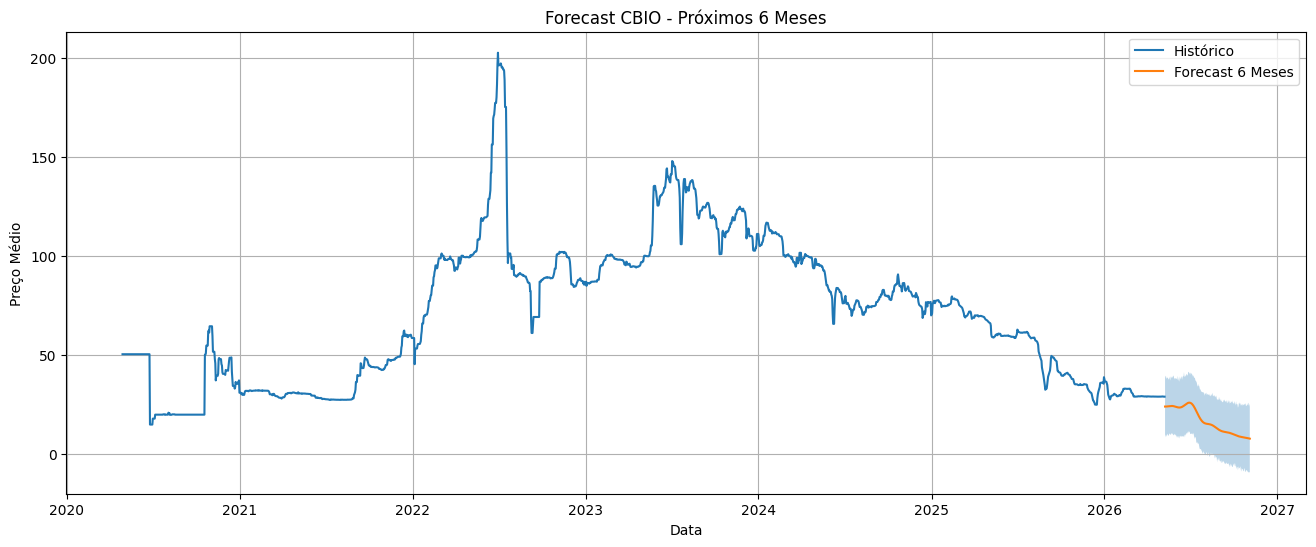

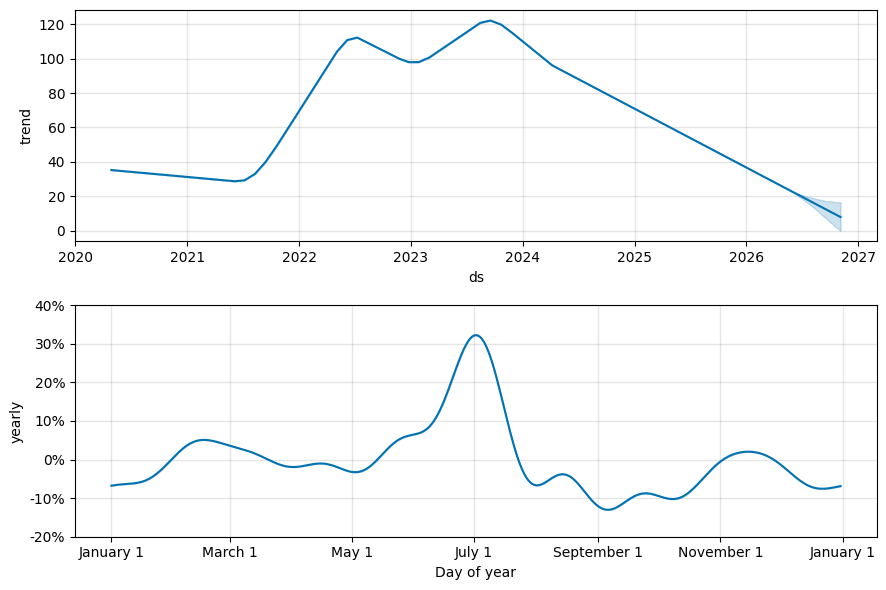

In [11]:
# Refit usando TODOS os dados
final_model = Prophet(
    **study.best_params
)

final_model.fit(df)

# Forecast - 6 meses
future_6m = final_model.make_future_dataframe(
    periods=180,
    freq='D'
)

forecast_6m = final_model.predict(future_6m)

# Apenas horizonte futuro
future_predictions = forecast_6m.tail(180)[
    [
        'ds',
        'yhat',
        'yhat_lower',
        'yhat_upper'
    ]
]

print(future_predictions.head())

# Plot
plt.figure(figsize=(16,6))

# Histórico real
plt.plot(
    df['ds'],
    df['y'],
    label='Histórico'
)
# Forecast futuro
plt.plot(
    future_predictions['ds'],
    future_predictions['yhat'],
    label='Forecast 6 Meses'
)
# Intervalo de confiança
plt.fill_between(
    future_predictions['ds'],
    future_predictions['yhat_lower'],
    future_predictions['yhat_upper'],
    alpha=0.3
)
plt.title('Forecast CBIO - Próximos 6 Meses')
plt.xlabel('Data')
plt.ylabel('Preço Médio')
plt.legend()
plt.grid(True)
plt.show()
# Componentes do Prophet
fig2 = final_model.plot_components(
    forecast_6m
)
plt.show()

15:58:09 - cmdstanpy - INFO - Chain [1] start processing
15:58:12 - cmdstanpy - INFO - Chain [1] done processing


             ds       yhat  yhat_lower  yhat_upper
2026 2026-05-09  29.750031   19.057907   40.477887
2027 2026-05-10  29.758040   18.323291   39.917777
2028 2026-05-11  29.891092   18.800072   39.899690
2029 2026-05-12  29.995230   18.160901   40.289856
2030 2026-05-13  30.053511   19.059724   40.566277


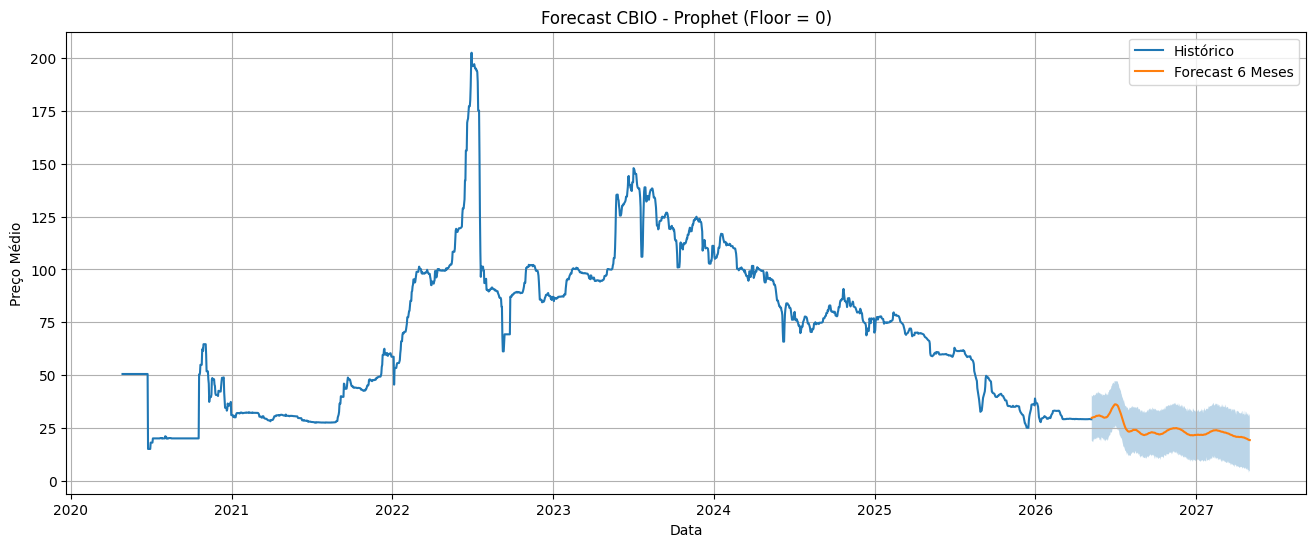

In [16]:
# Adiciona floor e cap
df['floor'] = 10

# cap é obrigatório quando usamos crescimento logístico
df['cap'] = df['y'].max() * 6

# Modelo final
final_model = Prophet(
    growth='logistic',
    **study.best_params
)

final_model.fit(df)

# Future dataframe
future_6m = final_model.make_future_dataframe(
    periods=360,
    freq='D'
)

# Mantém mesmas restrições
future_6m['floor'] = 15
future_6m['cap'] = df['cap'].max()

# Forecast
forecast_6m = final_model.predict(future_6m)

# Apenas futuro
future_predictions = forecast_6m.tail(360)[
    [
        'ds',
        'yhat',
        'yhat_lower',
        'yhat_upper'
    ]
]

print(future_predictions.head())


plt.figure(figsize=(16,6))
# Histórico
plt.plot(
    df['ds'],
    df['y'],
    label='Histórico'
)

# Forecast
plt.plot(
    future_predictions['ds'],
    future_predictions['yhat'],
    label='Forecast 6 Meses'
)

# Intervalo
plt.fill_between(
    future_predictions['ds'],
    future_predictions['yhat_lower'],
    future_predictions['yhat_upper'],
    alpha=0.3
)
plt.title('Forecast CBIO - Prophet (Floor = 0)')
plt.xlabel('Data')
plt.ylabel('Preço Médio')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# ============================================
# SALVANDO O MODELO PROPHET EM .PKL
# ============================================

import pickle

# Caminho do arquivo
model_path = "prophet_best_model_cbio.pkl"

# Salva o modelo
with open(model_path, "wb") as f:
    pickle.dump(final_model, f)

print(f"Modelo salvo em: {model_path}")

Modelo salvo em: prophet_best_model_cbio.pkl


Modelo carregado com sucesso!
             ds       yhat  yhat_lower  yhat_upper
2026 2026-05-09  29.750031   18.455032   39.902586
2027 2026-05-10  29.758040   18.748086   40.149222
2028 2026-05-11  29.891092   19.589496   40.156474
2029 2026-05-12  29.995230   19.381291   40.505112
2030 2026-05-13  30.053511   18.336438   40.876260

As previsões são idênticas? False


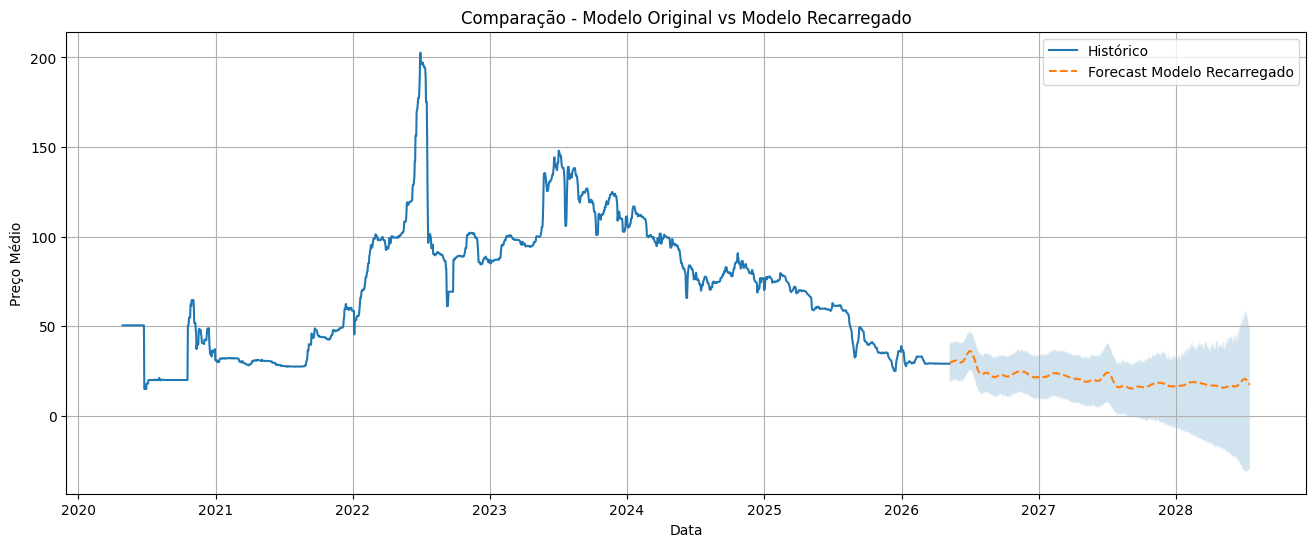

In [22]:
import pickle
import matplotlib.pyplot as plt

# Carrega o modelo salvo
with open("prophet_best_model_cbio.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("Modelo carregado com sucesso!")

h= 800

# Cria novamente o dataframe futuro
future_reload = loaded_model.make_future_dataframe(
    periods=h,
    freq='D'
)

# Reaplica floor e cap
future_reload['floor'] = 15
future_reload['cap'] = df['cap'].max()

# Nova previsão
forecast_reload = loaded_model.predict(future_reload)

# Apenas futuro
future_predictions_reload = forecast_reload.tail(h)[
    [
        'ds',
        'yhat',
        'yhat_lower',
        'yhat_upper'
    ]
]



# ============================================
# PLOT
# ============================================

plt.figure(figsize=(16,6))

# Histórico
plt.plot(
    df['ds'],
    df['y'],
    label='Histórico'
)


# Forecast recarregado
plt.plot(
    future_predictions_reload['ds'],
    future_predictions_reload['yhat'],
    '--',
    label='Forecast Modelo Recarregado'
)

plt.fill_between(
    future_predictions_reload['ds'],
    future_predictions_reload['yhat_lower'],
    future_predictions_reload['yhat_upper'],
    alpha=0.2
)

plt.title('Comparação - Modelo Original vs Modelo Recarregado')
plt.xlabel('Data')
plt.ylabel('Preço Médio')
plt.legend()
plt.grid(True)
plt.show()

Modelo carregado com sucesso!


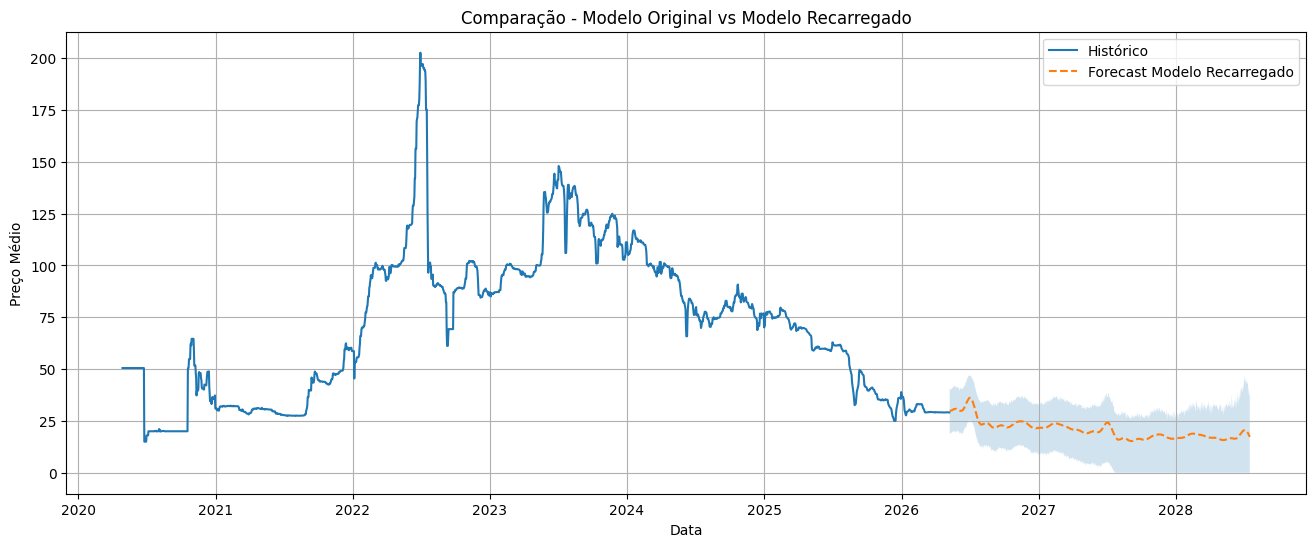

In [23]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Carrega o modelo salvo
with open("prophet_best_model_cbio.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("Modelo carregado com sucesso!")

h = 800

# Cria novamente o dataframe futuro
future_reload = loaded_model.make_future_dataframe(
    periods=h,
    freq='D'
)

# Reaplica floor e cap
future_reload['floor'] = 15
future_reload['cap'] = df['cap'].max()

# Nova previsão
forecast_reload = loaded_model.predict(future_reload)

# ============================================
# CLIP DOS VALORES NEGATIVOS
# max(0, x)
# ============================================

forecast_reload['yhat'] = np.maximum(0, forecast_reload['yhat'])
forecast_reload['yhat_lower'] = np.maximum(0, forecast_reload['yhat_lower'])
forecast_reload['yhat_upper'] = np.maximum(0, forecast_reload['yhat_upper'])

# Apenas futuro
future_predictions_reload = forecast_reload.tail(h)[
    [
        'ds',
        'yhat',
        'yhat_lower',
        'yhat_upper'
    ]
]

# ============================================
# PLOT
# ============================================

plt.figure(figsize=(16, 6))

# Histórico
plt.plot(
    df['ds'],
    df['y'],
    label='Histórico'
)

# Forecast recarregado
plt.plot(
    future_predictions_reload['ds'],
    future_predictions_reload['yhat'],
    '--',
    label='Forecast Modelo Recarregado'
)

plt.fill_between(
    future_predictions_reload['ds'],
    future_predictions_reload['yhat_lower'],
    future_predictions_reload['yhat_upper'],
    alpha=0.2
)

plt.title('Comparação - Modelo Original vs Modelo Recarregado')
plt.xlabel('Data')
plt.ylabel('Preço Médio')
plt.legend()
plt.grid(True)
plt.show()

### Com cap e floor

## Pre-treined Model

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from chronos import ChronosPipeline

In [90]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------- ----- 1.6/1.8 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 7.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.1
    Uninstalling pip-25.1:
      Successfully uninstalled pip-25.1
Note: you may need to restart the kernel to use updated packages.


In [95]:
df = CBIO.copy()

df['Data'] = pd.to_datetime(df['Data'])

df = df.sort_values('Data')

series = torch.tensor(
    df['Preço Médio'].values,
    dtype=torch.float32
)

In [96]:
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-large",
    device_map="cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype=torch.float32
)

C:\Users\aryck\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aryck\.cache\huggingface\hub\models--amazon--chronos-t5-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
`torch_dtype` is deprecated! Use `dtype` instead!


In [100]:
forecast = pipeline.predict(series, prediction_length=180)

median_forecast = forecast.median(dim=1).values[0].numpy()

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


In [102]:
future_dates = pd.date_range(
    start=df['Data'].max() + pd.Timedelta(days=1),
    periods=180,
    freq='D'
)

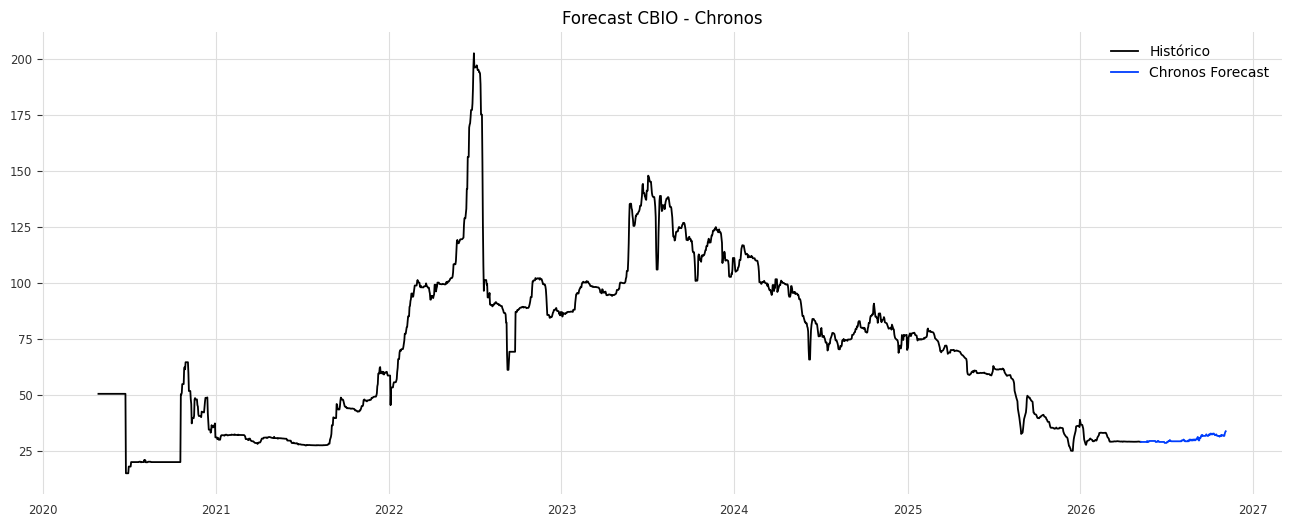

In [103]:
plt.figure(figsize=(16,6))
plt.plot(
    df['Data'],
    df['Preço Médio'],
    label='Histórico'
)
plt.plot(
    future_dates,
    median_forecast,
    label='Chronos Forecast'
)
plt.title('Forecast CBIO - Chronos')
plt.grid(True)
plt.legend()
plt.show()

In [104]:
import numpy as np
import torch
from transformers import TimesFmModelForPrediction

In [105]:
model = TimesFmModelForPrediction.from_pretrained(
    "google/timesfm-2.0-500m-pytorch",
    attn_implementation="sdpa",
    device_map="auto"
)

C:\Users\aryck\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aryck\.cache\huggingface\hub\models--google--timesfm-2.0-500m-pytorch. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some parameters are on the meta device because they were offloaded to the cpu and disk.


In [106]:
df = CBIO.copy()

df['Data'] = pd.to_datetime(df['Data'])

df = df.sort_values('Data').reset_index(drop=True)

In [ ]:
!conda create -n timesfm_env python=3.10
!conda activate timesfm_env
!pip install timesfm

In [109]:
# Installation
!pip install timesfm

# Import and initialize
import timesfm
import numpy as np

  Using cached timesfm-1.0.0-py3-none-any.whl.metadata (625 bytes)
  Using cached jax-0.4.26-py3-none-any.whl.metadata (23 kB)
  Using cached paxml-1.4.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached praxis-1.4.0-py3-none-any.whl.metadata (1.2 kB)
INFO: pip is looking at multiple versions of timesfm to determine which version is compatible with other requirements. This could take a while.


ERROR: Ignored the following versions that require a different python version: 0.0.11 Requires-Python >=3.10,<3.11; 0.0.12 Requires-Python >=3.10,<3.11; 0.1.1 Requires-Python >=3.10,<3.11; 0.1.14 Requires-Python >=3.10,<3.11; 0.1.15 Requires-Python >=3.10,<3.11; 0.1.16 Requires-Python >=3.10,<3.11; 0.1.17 Requires-Python >=3.10,<3.11; 0.1.18 Requires-Python >=3.10,<3.11; 0.1.2 Requires-Python >=3.10,<3.11; 0.1.21 Requires-Python >=3.10,<3.11; 0.1.22 Requires-Python >=3.10,<3.11; 0.1.23 Requires-Python >=3.10,<3.11; 0.1.24 Requires-Python >=3.10,<3.11; 0.1.25 Requires-Python >=3.10,<3.11; 0.1.3 Requires-Python >=3.10,<3.11; 0.1.31 Requires-Python >=3.10,<3.11; 0.1.32 Requires-Python >=3.10,<3.11; 0.1.4 Requires-Python >=3.10,<3.11; 0.1.5 Requires-Python >=3.10,<3.11; 0.1.6 Requires-Python >=3.10,<3.11; 0.1.7 Requires-Python >=3.10,<3.11; 1.0.1 Requires-Python >=3.10,<3.11; 1.1.0 Requires-Python >=3.10,<3.11; 1.2.0 Requires-Python >=3.10,<3.12; 1.2.1 Requires-Python >=3.10,<3.12; 1.2.2 R

ModuleNotFoundError: No module named 'timesfm'